This notebook demonstrates how to apply Principal Component Analysis (PCA) to reduce the dimensionality of our image data and visualize the results. The hypothesis is that we can visualize the image similarity on a plot and see how to approach a classifier for "clear sky", "cloudy sky", and so forth.

In [1]:
import numpy as np
from sklearn.decomposition import PCA, IncrementalPCA, KernelPCA
import matplotlib.pyplot as plt

from dask.array.image import imread

def load_images(selection):
    images = imread(f"../../images/{selection}/2025-10/*.JPG")[:,:,:,0].compute()
    return images

def get_pca_transform(pca: PCA | IncrementalPCA | KernelPCA, images, batch_size=None):
    images = images.reshape(images.shape[0], -1)

    transforms = []

    n_samples = images.shape[0]
    for start in range(0, n_samples, batch_size or ipca.batch_size):
        end = min(start + (batch_size or ipca.batch_size), n_samples)
        batch = images[start:end].reshape(end - start, -1)
        transforms.append(pca.transform(batch))

    return np.concatenate(transforms)

In [2]:
allsky_images = load_images("AllSkyImages")

In [3]:
ipca = IncrementalPCA(n_components=2, batch_size=8)
n_samples = allsky_images.shape[0]

for start in range(0, n_samples, ipca.batch_size):
    end = min(start + ipca.batch_size, n_samples)
    batch = allsky_images[start:end].reshape(end - start, -1)
    ipca.partial_fit(batch)

print(f"Explained variance ratio on {allsky_images.shape[0]} images: {ipca.explained_variance_ratio_}")

Explained variance ratio on 37002 images: [0.38752015 0.14683257]


In [5]:
allsky_reduction = get_pca_transform(ipca, allsky_images)
del allsky_images

In [9]:
nightsky_images = load_images("NightSkyImages")
nightsky_reduction = get_pca_transform(ipca, nightsky_images)
del nightsky_images

In [10]:
final_images = load_images("FinalSkyImages")
final_reduction = get_pca_transform(ipca, final_images)
del final_images

In [ ]:
pca = PCA(n_components=2)

allsky_images = load_images("AllSkyImages")
pca.fit(allsky_images.reshape(allsky_images.shape[0], -1))
print(f"Explained variance ratio on {allsky_images.shape[0]} images: {pca.explained_variance_ratio_}")
allsky_reduction = get_pca_transform(pca, allsky_images)
del allsky_images

nightsky_images = load_images("NightSkyImages")
nightsky_reduction = get_pca_transform(pca, nightsky_images)
del nightsky_images

final_images = load_images("FinalSkyImages")
final_reduction = get_pca_transform(pca, final_images)
del final_images

In [15]:
A_rows = allsky_reduction.view([('', allsky_reduction.dtype)] * allsky_reduction.shape[1])
B_rows = nightsky_reduction.view([('', nightsky_reduction.dtype)] * nightsky_reduction.shape[1])
excluded = np.setdiff1d(A_rows, B_rows).view(allsky_reduction.dtype).reshape(-1, allsky_reduction.shape[1])

C_rows = final_reduction.view([('', final_reduction.dtype)] * final_reduction.shape[1])
unselected = np.setdiff1d(B_rows, C_rows).view(nightsky_reduction.dtype).reshape(-1, nightsky_reduction.shape[1])

allsky_reduction.shape, nightsky_reduction.shape, final_reduction.shape, excluded.shape, unselected.shape

((37002, 2), (6635, 2), (1955, 2), (30367, 2), (4680, 2))

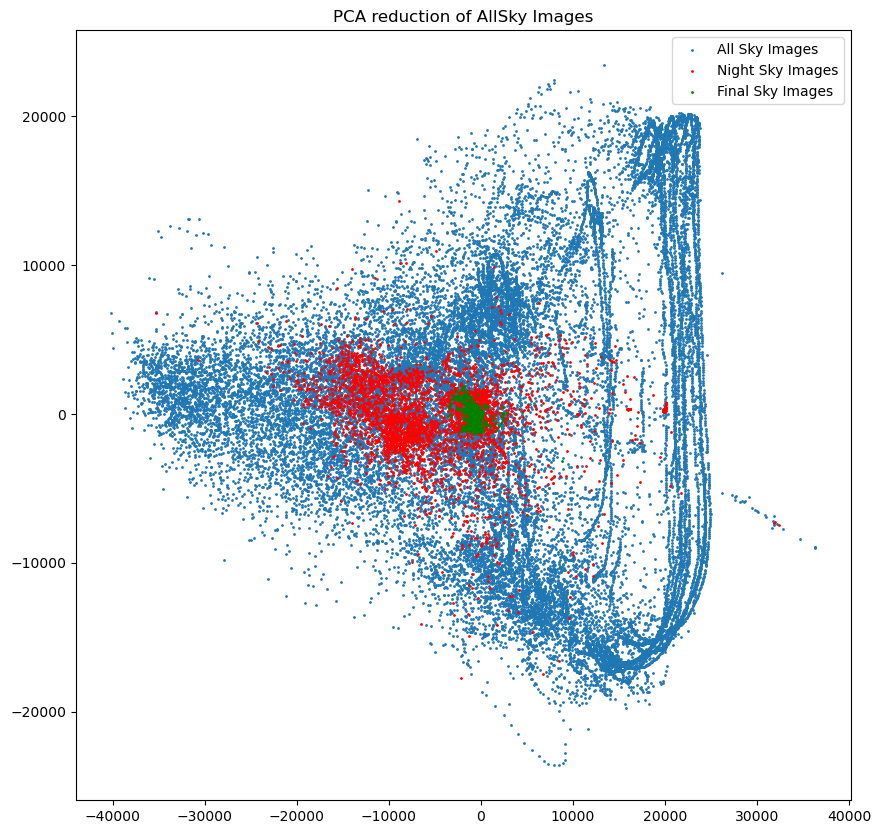

In [16]:
plt.figure(figsize=(10,10))
plt.title(f"PCA reduction of AllSky Images")
plt.scatter(excluded[:,0], excluded[:,1], s=1, label="All Sky Images")
plt.scatter(unselected[:,0], unselected[:,1], s=1, c="red", label="Night Sky Images")
plt.scatter(final_reduction[:,0], final_reduction[:,1], s=1, c="green", label="Final Sky Images")
plt.legend()

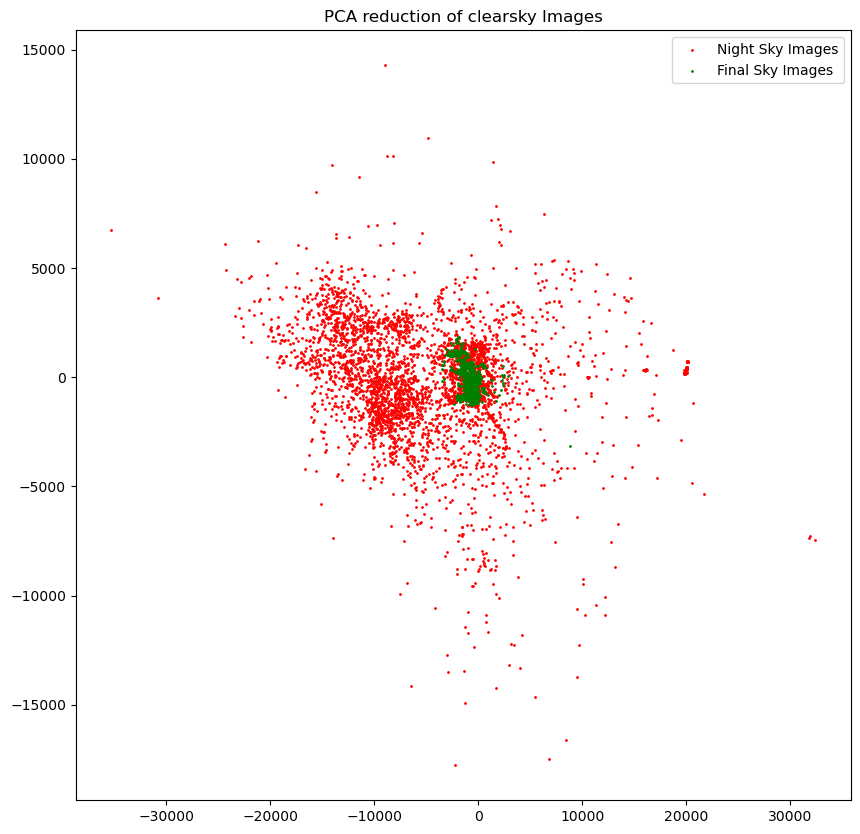

In [18]:
plt.figure(figsize=(10,10))
plt.title(f"PCA reduction of clearsky Images")
plt.scatter(unselected[:,0], unselected[:,1], s=1, c="red", label="Night Sky Images")
plt.scatter(final_reduction[:,0], final_reduction[:,1], s=1, c="green", label="Final Sky Images")
plt.legend()

In future examples I should take a look at the nonlinear RBF Kernel PCA to see how and if it pulls the groups apart